# Chinese dynasties
Counts individuals per Chinese dynasty (Shang → Qing) and the temporal precision of their dates.

In [1]:
import random
import tempfile

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import FuncFormatter, PercentFormatter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'

COLORS = {
    'year':    '#7fa7cc',
    'decade':  '#f2c48d',
    'century': '#d9e4ef',
}

plt.rcParams.update({
    'figure.dpi':        120,
    'figure.figsize':    (17, 10),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.labelsize':    16,
    'xtick.labelsize':   14,
    'ytick.labelsize':   14,
    'legend.fontsize':   14,
})

## External data — none

## Chinese dynasty list

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

CHINESE_DYNASTIES = con.sql('''
    SELECT name, list_min(list_transform(territories, t -> t.start_year)) AS first_year
    FROM polity
    WHERE list_contains(world, 'Chinese world')
    ORDER BY first_year, name
''').pl()['name'].to_list()
assert len(set(CHINESE_DYNASTIES)) == len(CHINESE_DYNASTIES)
print(f'Chinese-world polities: {len(CHINESE_DYNASTIES)}')
print(CHINESE_DYNASTIES)

Chinese-world polities: 24
['Shang Dynasty', 'Zhou Dynasty', 'Qin Dynasty', 'Han Dynasty', 'Xin Dynasty', 'Western Jin', 'Northern Wei', 'Liu Song Dynasty', 'Liang Dynasty', 'Eastern Wei', 'Western Wei', 'Northern Qi', 'Chen Dynasty', 'Northern Zhou', 'Sui Dynasty', 'Tang Dynasty', 'Five Dynasties and Ten Kingdoms', 'Liao Dynasty', 'Northern Song', 'Western Xia', 'Southern Song', 'Yuan Dynasty', 'Ming Dynasty', 'Qing Dynasty']


## Load data
### Dynasty periods

In [3]:
dynasty_periods = con.sql("""
    SELECT name AS dynasty,
           MIN(t.start_year) AS from_year,
           MAX(t.end_year)   AS to_year
    FROM   (SELECT name, unnest(territories) AS t FROM polity WHERE list_contains($names, name))
    GROUP  BY name
""", params={'names': CHINESE_DYNASTIES}).pl()

assert dynasty_periods['dynasty'].is_unique
print('shape:', dynasty_periods.shape)
dynasty_periods.sort('from_year').head()

shape: (24, 3)


dynasty,from_year,to_year
str,i64,i64
"""Shang Dynasty""",-1600,-1001
"""Zhou Dynasty""",-1000,-751
"""Qin Dynasty""",-218,-209
"""Han Dynasty""",-202,237
"""Xin Dynasty""",6,29


### Individuals per dynasty

In [4]:
dynasty_individuals = con.sql("""
    WITH matches AS (
        SELECT entity.qid                       AS qid,
               p.polity.name                    AS dynasty,
               peak_productivity.start_year     AS peak_start,
               peak_productivity.end_year       AS peak_end,
               peak_productivity.assignation_method AS peak_method
        FROM   (SELECT entity, peak_productivity, unnest(polity) AS p FROM individual_enriched)
        WHERE  list_contains($names, p.polity.name)
    )
    SELECT matches.*,
           i.birth_date[1].precision   AS birth_precision,
           i.death_date[1].precision   AS death_precision,
           i.floruit_date[1].precision AS floruit_precision
    FROM   matches
    JOIN   individual AS i ON i.entity.qid = matches.qid
""", params={'names': CHINESE_DYNASTIES}).pl()

con.close()

assert dynasty_individuals.select('qid', 'dynasty').is_duplicated().sum() == 0
print('shape:', dynasty_individuals.shape)
print('distinct individuals:', dynasty_individuals['qid'].n_unique())
dynasty_individuals.head()

shape: (94383, 8)
distinct individuals: 89606


qid,dynasty,peak_start,peak_end,peak_method,birth_precision,death_precision,floruit_precision
str,str,i64,i64,str,str,str,str
"""Q11487595""","""Qing Dynasty""",1840,1864,"""death_only_wikidata_property""",null,"""year""",null
"""Q11487599""","""Qing Dynasty""",1842,1861,"""birth_death_wikidata_property""","""year""","""year""",null
"""Q11487640""","""Western Jin""",277,301,"""death_only_wikidata_property""","""century""","""year""",null
"""Q11487664""","""Qing Dynasty""",1844,1868,"""death_only_wikidata_property""",null,"""year""",null
"""Q11487666""","""Qing Dynasty""",1852,1872,"""birth_death_wikidata_property""","""year""","""year""",null


## Preprocessing
### Counts per dynasty

In [5]:
dynasty_counts = (
    dynasty_individuals
    .group_by('dynasty')
    .agg(
        pl.len().alias('all_individuals'),
        pl.col('peak_method').is_not_null().sum().alias('with_peak_window'),
    )
)

dynasty_summary = (
    pl.DataFrame({'dynasty': CHINESE_DYNASTIES})
    .join(dynasty_periods, on='dynasty', how='left')
    .join(dynasty_counts, on='dynasty', how='left')
    .with_columns(pl.col('all_individuals', 'with_peak_window').fill_null(0))
    .with_columns(
        (pl.col('all_individuals') - pl.col('with_peak_window')).alias('missing_peak_window'),
        (100 * pl.col('with_peak_window') / pl.col('all_individuals')).round(1).alias('pct_with_peak_window'),
    )
)

assert dynasty_summary['all_individuals'].sum() == dynasty_individuals.height
assert dynasty_summary['missing_peak_window'].sum() == 0
print('shape:', dynasty_summary.shape)
dynasty_summary.head(len(CHINESE_DYNASTIES))

shape: (24, 7)


dynasty,from_year,to_year,all_individuals,with_peak_window,missing_peak_window,pct_with_peak_window
str,i64,i64,u32,u32,u32,f64
"""Shang Dynasty""",-1600,-1001,9,9,0,100.0
"""Zhou Dynasty""",-1000,-751,24,24,0,100.0
"""Qin Dynasty""",-218,-209,93,93,0,100.0
"""Han Dynasty""",-202,237,1211,1211,0,100.0
"""Xin Dynasty""",6,29,83,83,0,100.0
…,…,…,…,…,…,…
"""Western Xia""",990,1226,19,19,0,100.0
"""Southern Song""",1028,1278,6416,6416,0,100.0
"""Yuan Dynasty""",1294,1374,3051,3051,0,100.0


### Temporal precision

In [6]:
PRECISION_BUCKET = {'day': 'year', 'month': 'year', 'year': 'year', 'decade': 'decade',
                    'century': 'century', 'millennium': 'century'}
PRECISION_COLUMNS = ['year', 'decade', 'century']

source_precision = (
    pl.when(pl.col('peak_method') == 'floruit_wikidata_property').then(pl.col('floruit_precision'))
      .when(pl.col('peak_method').str.starts_with('birth')).then(pl.col('birth_precision'))
      .when(pl.col('peak_method') == 'death_only_wikidata_property').then(pl.col('death_precision'))
      .when(pl.col('peak_method').str.starts_with('works')).then(pl.lit('year'))
)

dynasty_precision = dynasty_individuals.with_columns(
    source_precision.replace_strict(PRECISION_BUCKET, default=None).alias('precision')
)
assert dynasty_precision['precision'].null_count() == 0
print(dynasty_precision.group_by('peak_method', 'precision').len().sort('len', descending=True).head(15))

precision_counts = (
    pl.DataFrame({'dynasty': CHINESE_DYNASTIES})
    .join(dynasty_precision.pivot(on='precision', index='dynasty', values='qid', aggregate_function='len'),
          on='dynasty', how='left')
)
for column in PRECISION_COLUMNS:
    if column not in precision_counts.columns:
        precision_counts = precision_counts.with_columns(pl.lit(0).alias(column))
precision_counts = (
    precision_counts
    .with_columns(pl.col(PRECISION_COLUMNS).fill_null(0).cast(pl.Int64))
    .with_columns(pl.sum_horizontal(PRECISION_COLUMNS).alias('total'))
    .select('dynasty', *PRECISION_COLUMNS, 'total')
)

assert precision_counts['total'].sum() == dynasty_individuals.height
print('shape:', precision_counts.shape)
precision_counts.head(len(CHINESE_DYNASTIES))

shape: (14, 3)
┌───────────────────────────────┬───────────┬───────┐
│ peak_method                   ┆ precision ┆ len   │
│ ---                           ┆ ---       ┆ ---   │
│ str                           ┆ str       ┆ u32   │
╞═══════════════════════════════╪═══════════╪═══════╡
│ birth_death_wikidata_property ┆ year      ┆ 36830 │
│ death_only_wikidata_property  ┆ year      ┆ 31102 │
│ birth_only_wikidata_property  ┆ year      ┆ 24048 │
│ birth_only_wikidata_property  ┆ century   ┆ 764   │
│ works_single                  ┆ year      ┆ 748   │
│ …                             ┆ …         ┆ …     │
│ floruit_wikidata_property     ┆ century   ┆ 39    │
│ death_only_wikidata_property  ┆ century   ┆ 18    │
│ birth_death_wikidata_property ┆ decade    ┆ 9     │
│ death_only_wikidata_property  ┆ decade    ┆ 9     │
│ floruit_wikidata_property     ┆ decade    ┆ 5     │
└───────────────────────────────┴───────────┴───────┘
shape: (24, 5)


dynasty,year,decade,century,total
str,i64,i64,i64,i64
"""Shang Dynasty""",7,0,2,9
"""Zhou Dynasty""",20,0,4,24
"""Qin Dynasty""",69,3,21,93
"""Han Dynasty""",947,12,252,1211
"""Xin Dynasty""",83,0,0,83
…,…,…,…,…
"""Western Xia""",19,0,0,19
"""Southern Song""",6377,3,36,6416
"""Yuan Dynasty""",2989,2,60,3051


## Figures
### Fig 1 — Temporal precision per dynasty

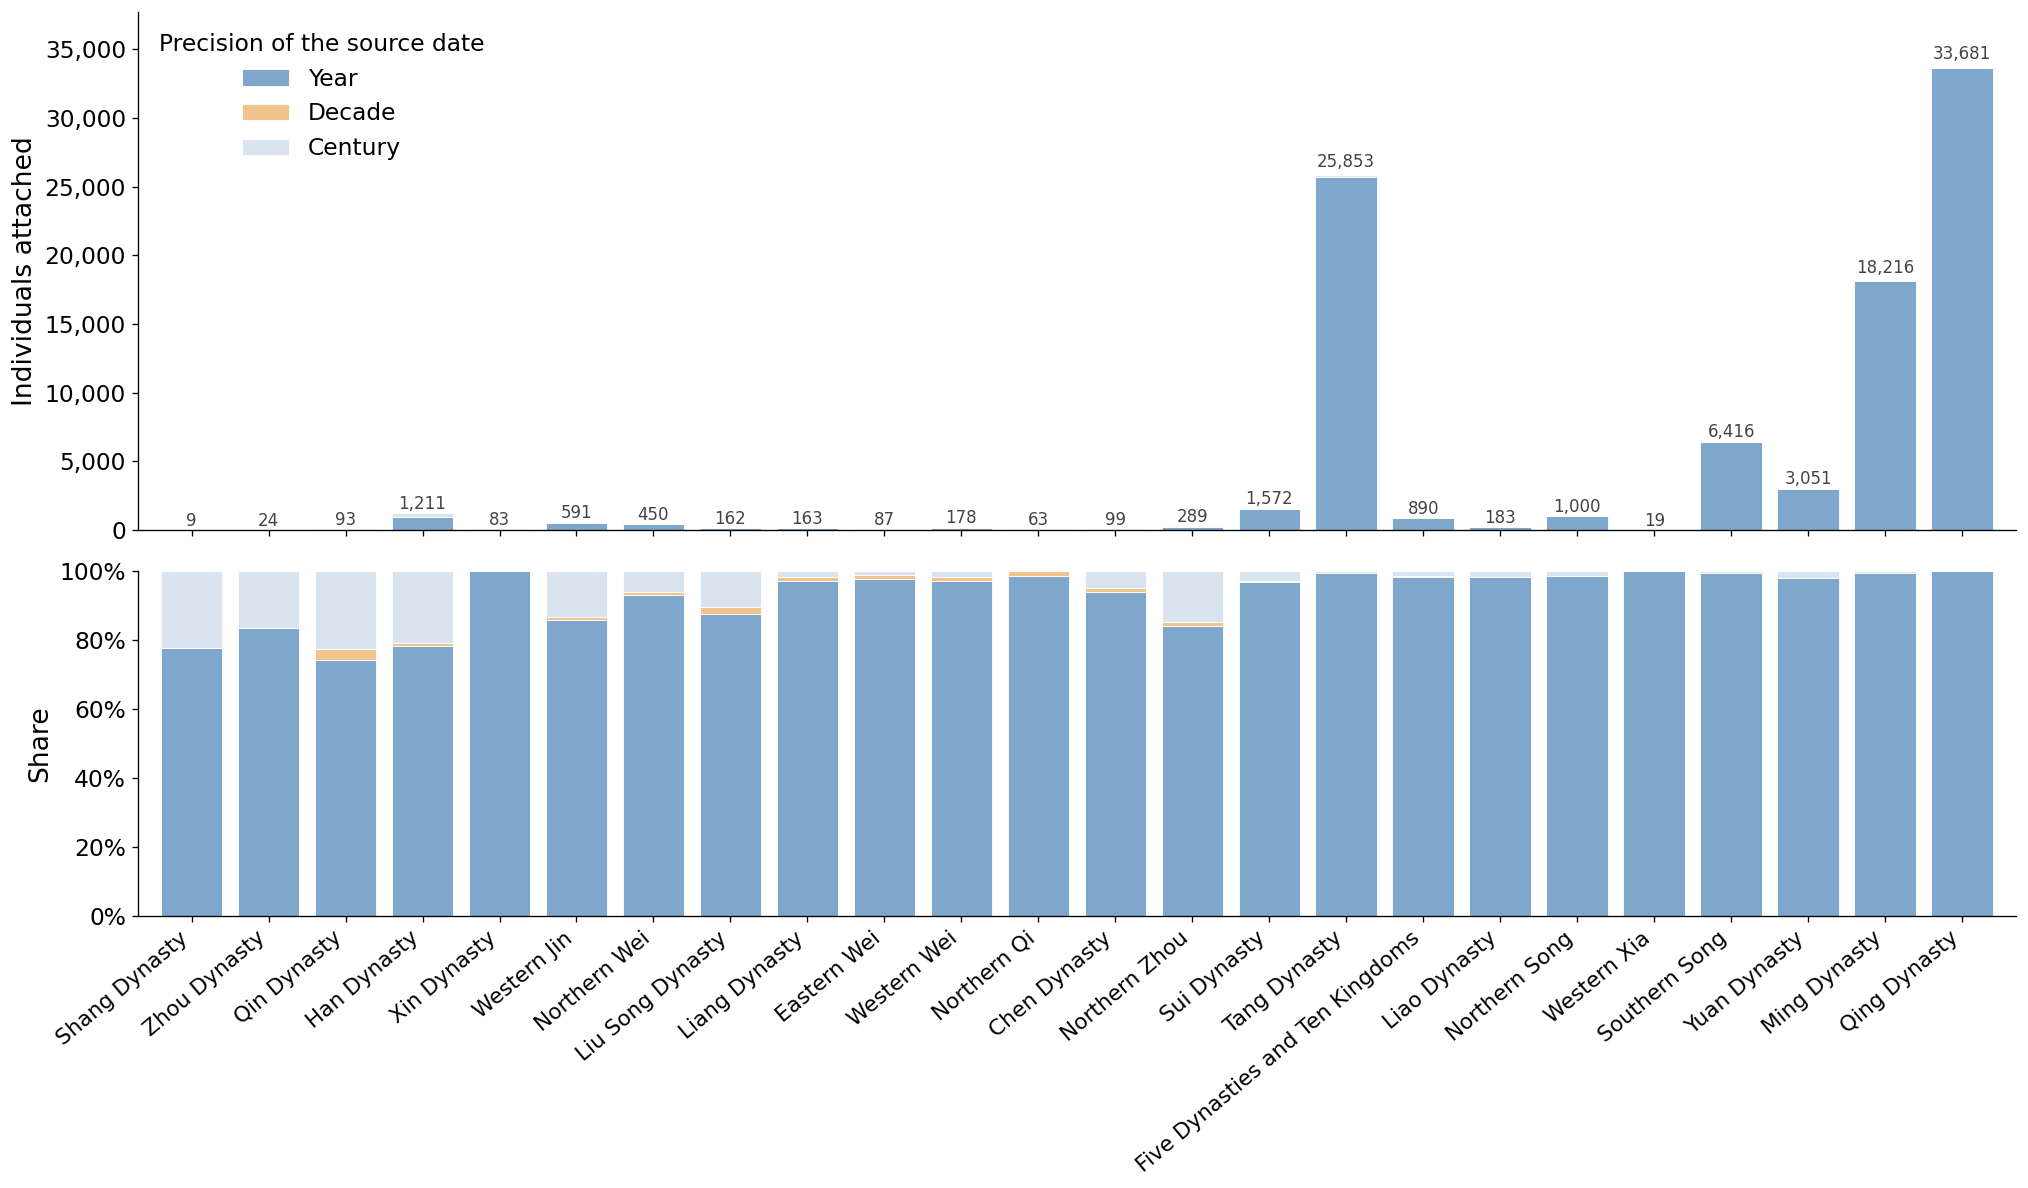

In [7]:
PRECISION_LABELS = {'year': 'Year', 'decade': 'Decade', 'century': 'Century'}

dynasty_axis = precision_counts['dynasty'].to_list()
totals = precision_counts['total'].to_numpy().astype(float)
xs = np.arange(len(dynasty_axis))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 2]})

bottoms = np.zeros(len(xs))
for column in PRECISION_COLUMNS:
    counts = precision_counts[column].to_numpy().astype(float)
    ax_top.bar(xs, counts, bottom=bottoms, color=COLORS[column], edgecolor='white',
               linewidth=0.5, label=PRECISION_LABELS[column])
    bottoms += counts
for x, total in zip(xs, totals):
    if total > 0:
        ax_top.text(x, total * 1.01, f'{int(total):,}', ha='center', va='bottom', fontsize=10, color='#444')
ax_top.set_ylim(0, totals.max() * 1.12)
ax_top.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v):,}'))
ax_top.set_ylabel('Individuals attached')
ax_top.legend(frameon=False, loc='upper left', title='Precision of the source date', title_fontsize=14)

shares = precision_counts.select(PRECISION_COLUMNS).to_numpy() / np.where(totals == 0, np.nan, totals)[:, None]
shares = np.nan_to_num(shares)
bottoms = np.zeros(len(xs))
for j, column in enumerate(PRECISION_COLUMNS):
    ax_bot.bar(xs, shares[:, j], bottom=bottoms, color=COLORS[column], edgecolor='white', linewidth=0.5)
    bottoms += shares[:, j]
ax_bot.set_xticks(xs)
ax_bot.set_xticklabels(dynasty_axis, rotation=40, ha='right', fontsize=13)
ax_bot.set_xlim(-0.7, len(xs) - 0.3)
ax_bot.set_ylim(0, 1)
ax_bot.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax_bot.set_ylabel('Share')

fig.tight_layout()
plt.show()